In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

#from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
from IPython.display import clear_output
import re

import ipycytoscape
import torch

from pyvis.network import Network
import os
from datetime import datetime
import json

DEBUG = True
NOISE_RANGE = 0
SAVE_PATH = "Sim_Raw_data.parquet"
SAVE_PATH_GRAPH = 'Sim_Graph.json'

In [2]:


def propagate_demand_upwards(G: nx.DiGraph, flow_attr='flow') -> nx.DiGraph:
    """
    Calculates flow for all edges in a DAG by propagating demand from 
    bottom leaf edges upwards to the top sources.
    
    Args:
        G: A NetworkX DiGraph (must be Acyclic).
           'Leaf edges' (edges pointing to nodes with out_degree=0) must 
           have the 'flow' attribute set.
        flow_attr: The attribute name for the flow value.
        
    Returns:
        The DiGraph with calculated flows on all edges.
    """
    # Work on a copy to preserve original structure
    H = G.copy()

    # 1. Verification: Ensure it is a DAG (Cycles break Kirchhoff's logic)
    if not nx.is_directed_acyclic_graph(H):
        raise ValueError("Graph contains a cycle. Kirchhoff propagation requires a DAG.")

    # 2. Initialize flow on non-leaf edges to 0 to be safe
    for u, v, data in H.edges(data=True):
        if flow_attr not in data:
            data[flow_attr] = 0.0

    # 3. Get Reverse Topological Sort
    # We process children before parents.
    # The last nodes in a topo sort are the leaves; reversed means we start with them.
    try:
        nodes_bottom_up = list(reversed(list(nx.topological_sort(H))))
    except nx.NetworkXUnfeasible:
        raise ValueError("Graph cycle detected during sort.")

    # 4. Propagate Flow Upwards
    for node in nodes_bottom_up:
        # Step A: Calculate how much this node OUTPUTS (Demand)
        out_edges = H.out_edges(node, data=True)
        
        # If it's a leaf node, it doesn't output to other nodes, 
        # but the edges *entering* it carry the flow we start with.
        # We need to calculate the flow for the edges ENTERING this node.
        
        # Calculate the total flow leaving this node
        total_out_flow = sum(data.get(flow_attr, 0.0) for _, _, data in out_edges)
        
        # NOTE: If this is a true "Leaf" (out_degree=0), total_out_flow is 0.
        # But wait - the prompt says "flow is attribute in the LEAF EDGES".
        # This implies the edges *entering* the leaves already have values.
        # So we actually need to process 'Internal Nodes' that feed these leaves.
        
        # If total_out_flow is 0, check if this node is a sink that was manually set?
        # No, the flow is on the *edge*. 
        # So if I am Node B, and I point to Leaf C (B->C), B->C has flow.
        # I just summed B->C. Now I need to supply B's parents.

        # Step B: Identify Parents (Incoming Edges)
        in_edges = list(H.in_edges(node))
        num_parents = len(in_edges)

        if num_parents > 0:
            # If the node has output flow, it must request that amount from inputs.
            # However, if this node is a Leaf, it has NO output edges.
            # But the edge pointing TO it (Parent->Leaf) is the one with the value.
            # We don't need to calculate the flow for the edge pointing to the leaf 
            # (it's already there). We need to calculate the flow for the Parent's Parent.
            
            # So, strictly speaking, we only need to act if we are an INTERNAL node
            # whose out-edges have just been summed up.
            
            # If total_out_flow > 0, we propagate it up.
            if total_out_flow > 0:
                flow_per_parent = total_out_flow / num_parents
                
                for parent, _ in in_edges:
                    # Set the flow for the incoming edge (Parent -> Node)
                    # We use += because a parent might have multiple children 
                    # causing it to accumulate demand from different branches.
                    # BUT: Since we initialize to 0 and visit each edge once from the child side,
                    # we can technically just set it, but += is safer for aggregation logic.
                    
                    current_val = H[parent][node].get(flow_attr, 0.0)
                    
                    # If this edge was a "leaf edge" preset by the user, we shouldn't overwrite it?
                    # The user said leaf edges have attributes. Upper edges don't.
                    # We only overwrite if it's 0 (calculated).
                    if current_val == 0.0:
                         H[parent][node][flow_attr] = flow_per_parent
                    else:
                        # If the edge already has flow (e.g., it's a leaf edge), 
                        # we use that value for the sum, but we don't change it.
                        pass

    return H

def draw_flow_graph_spaced(G, flow_attr='flow', spacing=2.0):
    plt.figure(figsize=(8 * spacing, 6 * spacing))
    
    # 1. Layout logic
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for node in nodes: 
            G.nodes[node]['layer'] = layer
    pos = nx.multipartite_layout(G, subset_key='layer', align='horizontal', scale=spacing)

    # 2. Identify Nodes
    leaf_nodes = [n for n, d in G.out_degree() if d == 0]
    regular_nodes = [n for n in G.nodes() if n not in leaf_nodes]

    # 3. Draw Nodes (Draw these first)
    nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes, node_size=2500, node_color='white', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=leaf_nodes, node_size=2500, node_color='lightgreen', edgecolors='darkgreen')
    nx.draw_networkx_labels(G, pos, font_size=12)

    # 4. Draw Edges (PUT ARROWS HERE)
    nx.draw_networkx_edges(
        G, pos, 
        node_size=2500,          # Tells arrows where to stop so they are visible
        arrows=True,              # Valid here
        arrowstyle='-|>',         # Solid triangle head
        arrowsize=40,             # Large enough to see
        edge_color='#555555', 
        width=2,
        min_target_margin=25      # Forces the arrow tip to stay outside the node circle
    )

    # 5. Draw Edge Labels (TEXT ONLY)
    edge_labels = {
        (u, v): f"{d[flow_attr]:.1f}" 
        for u, v, d in G.edges(data=True) if flow_attr in d
    }
    
    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, # No 'arrows' or 'arrow' argument here!
        font_color='darkred', 
        font_size=11, 
        font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )

    plt.axis('off')
    plt.show()

def draw_flow_graph_spaced_df(G,df):

    _attr = df.columns[-1]
    print(_attr)
   
    _h = nx.from_pandas_edgelist(df, 
                            source=0, 
                            target=1, 
                            edge_attr=True, 
                            create_using=nx.DiGraph()
                            )

    draw_flow_graph_spaced(_h, flow_attr=_attr)
    
def reconsruct_flows(G, flows:dict):
    H = G.copy()

    for _leaf_node,_flow in flows.items():
        _edge_leaf = [x for x in H.edges() if x[1] == _leaf_node]
        H.edges[_edge_leaf[0]]["flow"] = float(_flow)

    H = propagate_demand_upwards(H)
    return H




# CREATE THE GRAPH

In [3]:

G_router = nx.DiGraph()
G_router.add_edge('HR_A', 'MR_A', capacity=10000)
G_router.add_edge('HR_B', 'MR_B', capacity=10000)
G_router.add_edge('MR_B', 'MR_A', capacity=10000)
G_router.add_edge('MR_A', 'C', capacity=10000)

G_router.add_edge('C', 'D', capacity=10000)
G_router.add_edge('MR_B', 'A', capacity=10000)
G_router.add_edge('A', 'B', capacity=10000)
G_router.add_edge('B', 'D', capacity=10000)
G_router.add_edge('D', 'E', capacity=10000)

G_router.add_edge('C', 'S7', capacity=10000)
G_router.add_edge('D', 'S6', capacity=10000)
G_router.add_edge('D', 'S5', capacity=10000)
G_router.add_edge('B', 'S3', capacity=10000)
G_router.add_edge('A', 'S1', capacity=10000)
G_router.add_edge('A', 'S2', capacity=10000)
G_router.add_edge('E', 'S4', capacity=10000)


print(f"Nodes: {G_router.nodes()}")
print(f"Edges: {G_router.edges()}")

Nodes: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']
Edges: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# CREATING DEMANDS

In [4]:
RANGES_DEMANDS = {
    'S1': (800, 1000),
    'S2': (10, 30),
    'S3': (100, 200),
    'S4': (500, 600),
    'S5': (300, 400),
    'S6': (100, 200),
    'S7': (50, 60)
}

In [5]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)
    
def create_day_demand(day:datetime, node:str, amp_range:int = (10, 1000), skewness_range:int = (-30,-25), sigma_range:int = (35, 40), nn:int = 1440, points:int = 288):   # skewness -6,-5    sigma 10,15   point24

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='5min') #h
    _curve = _curve * _max_val/_curve.max()

    ## PATCHS ###
    _curve = _curve.shift(3).bfill()
    _curve[(_curve.index.hour > 15) & (_curve.index.hour < 20)] *= 1.4
    _curve[(_curve.index.hour > 21)] *= 1.4
    _curve[(_curve.index.hour < 13)] *= 1.5

    _fix_val = _curve.quantile(.25)
    _fix_val_len = len(_curve[(_curve < _fix_val)])
    _curve[(_curve < _fix_val)] = np.random.rand(_fix_val_len)*_curve.quantile(.5)

    return _curve



from random import randint

DEMANDS_NODES = [x for x in G_router.nodes() if re.match(r'.*S\d+', x)]
print(f"Nodes con demanda: {DEMANDS_NODES}")
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')

DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _range_amp = RANGES_DEMANDS[_node]
        if randint(0,100) == 10:
            print("add valley")
            _range_amp = (int(_range_amp[0]*0.5), int(_range_amp[1]*0.5))
        if randint(0,100) == 10:
            print("add peak")
            _range_amp = (int(_range_amp[0]*1.5), int(_range_amp[1]*1.5))

        _demands_day[_node] = create_day_demand(_day, _node, amp_range=_range_amp)

    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)
DEMANDS

Nodes con demanda: ['S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']
add peak
add valley
add peak
add valley
add peak
add peak
add peak
add valley
add valley
add peak
add peak
add peak
add peak
add peak
add peak
add peak
add valley
add valley
add valley
add peak
add valley


,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,1.354839,4.450000,7.828125,9.350870,21.738462,0.392308,10.038462
2024-01-01 00:05:00,1.354839,4.450000,7.828125,19.162418,21.738462,0.392308,10.038462
2024-01-01 00:10:00,1.354839,4.450000,7.828125,3.739441,21.738462,0.392308,10.038462
2024-01-01 00:15:00,1.354839,4.450000,7.828125,10.244475,21.738462,0.392308,10.038462
2024-01-01 00:20:00,2.185772,7.473280,45.126004,23.728074,73.829364,0.593925,0.000000
...,...,...,...,...,...,...,...
2024-06-28 23:35:00,42.541333,78.120000,218.295522,98.181818,976.402778,7.985185,574.933333
2024-06-28 23:40:00,35.616000,95.480000,147.877612,41.454545,745.616667,6.464198,328.533333
2024-06-28 23:45:00,26.712000,63.653333,98.585075,58.909091,905.391667,4.943210,176.000000
2024-06-28 23:50:00,16.818667,52.080000,112.668657,32.727273,550.336111,3.041975,211.200000


<Axes: >

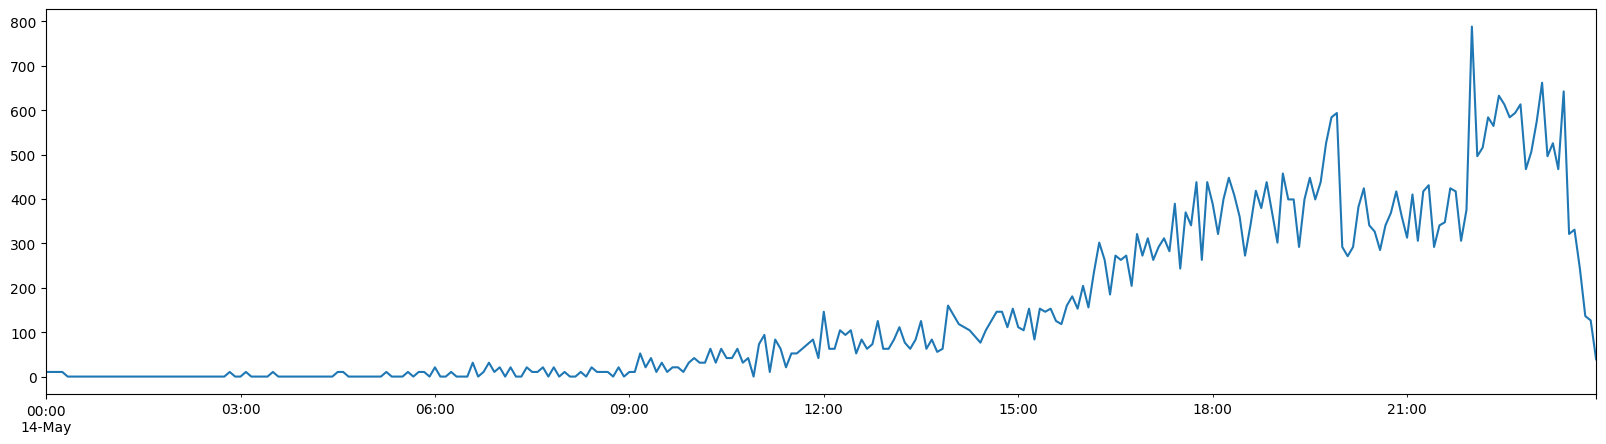

In [6]:
T = DEMANDS.loc[(DEMANDS.index.day == 14) & (DEMANDS.index.month == 5), 'S4' ]
T.plot(figsize=(20,5))


<Axes: >

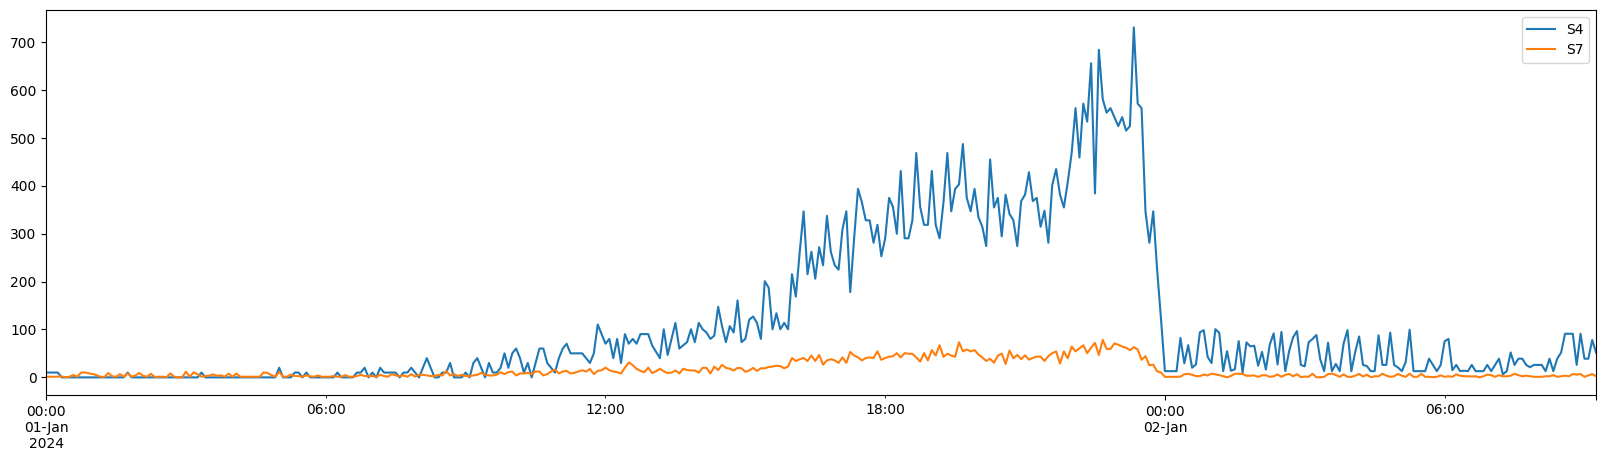

In [7]:
DEMANDS[['S4','S7']].iloc[:400].plot(figsize=(20,5))

# RECONTRUCT THE EDGES

In [8]:
def calculate_upward_flow(G, leaf_flows):
    """
    G: A directed acyclic graph (DAG).
    leaf_flows: A dict {node: flow_value} for the starting leaf nodes.
    """
    # 1. Initialize all node and edge flows to 0
    node_flows = {node: 0.0 for node in G.nodes()}
    edge_flows = {}

    # 2. Assign initial flows to the leaf nodes
    for node, flow in leaf_flows.items():
        node_flows[node] = flow

    # 3. Get Reverse Topological Order (Bottom-Up)
    # This ensures children are processed before parents
    nodes_bottom_up = list(nx.topological_sort(G))[::-1]

    for v in nodes_bottom_up:
        # The flow leaving this node is its accumulated node_flow
        current_flow = node_flows[v]
        
        # Get predecessors (the "upward" targets)
        preds = list(G.predecessors(v))
        
        if preds:
            # Distribute the flow to predecessors
            # Here we split it equally, but you could use edge weights
            flow_per_pred = current_flow / len(preds)
            
            for u in preds:
                edge_flows[(u, v)] = flow_per_pred
                node_flows[u] += flow_per_pred

    return node_flows, edge_flows

def calculate_network_flow(G, known_flows):
    """
    Propagates flow values through the network using Kirchhoff's Law.
    Works bi-directionally (can solve Parents from Children, or Children from Parents).
    
    Args:
        G (nx.DiGraph): The topology.
        known_flows (dict): Dictionary of known node flows (e.g., {'S4': 100, 'HR_A': 500}).
        
    Returns:
        dict: A dictionary containing flows for ALL solvable nodes.
    """
    # 1. Start with what we know
    solved_flows = known_flows.copy()
    
    # 2. Iterate until we stop making progress
    while True:
        progress_made = False
        
        # Get list of nodes we haven't solved yet
        unknown_nodes = [n for n in G.nodes() if n not in solved_flows]
        
        if not unknown_nodes:
            break # All solved!
            
        for node in unknown_nodes:
            parents = list(G.predecessors(node))
            children = list(G.successors(node))
            
            # --- STRATEGY A: Aggregation (Calculate from Parents) ---
            # "I am a sink for my parents. My flow is their sum."
            # Condition: We must know ALL parents.
            if len(parents) > 0 and all(p in solved_flows for p in parents):
                total_in = sum(solved_flows[p] for p in parents)
                solved_flows[node] = total_in
                progress_made = True
                continue 

            # --- STRATEGY B: Source Calculation (Calculate from Children) ---
            # "I am a source for my children. My flow is their sum."
            # Condition: We must know ALL children.
            if len(children) > 0 and all(c in solved_flows for c in children):
                total_out = sum(solved_flows[c] for c in children)
                solved_flows[node] = total_out
                progress_made = True
                continue
                
        # If we went through all nodes and found nothing new, we are stuck
        if not progress_made:
            print(f"⚠️ Calculation stopped. {len(unknown_nodes)} nodes are unsolvable (Ambiguous Split).")
            print(f"Unsolved: {unknown_nodes}")
            break
            
    return solved_flows


RAW_DATA = []
for _date,_flows in DEMANDS.iterrows():
    _flow_node = calculate_network_flow(G_router,_flows.to_dict())
    _row = pd.DataFrame(_flow_node, index=[_date])
    RAW_DATA.append(_row)
    
RAW_DATA = pd.concat(RAW_DATA)
RAW_DATA

,S7,S6,S5,S3,S1,S2,S4,E,D,B,C,A,MR_A,MR_B,HR_A,HR_B
2024-01-01 00:00:00,1.354839,4.450000,7.828125,9.350870,21.738462,0.392308,10.038462,10.038462,22.316587,31.667456,23.671425,53.798225,23.671425,77.469651,23.671425,77.469651
2024-01-01 00:05:00,1.354839,4.450000,7.828125,19.162418,21.738462,0.392308,10.038462,10.038462,22.316587,41.479004,23.671425,63.609774,23.671425,87.281199,23.671425,87.281199
2024-01-01 00:10:00,1.354839,4.450000,7.828125,3.739441,21.738462,0.392308,10.038462,10.038462,22.316587,26.056028,23.671425,48.186797,23.671425,71.858222,23.671425,71.858222
2024-01-01 00:15:00,1.354839,4.450000,7.828125,10.244475,21.738462,0.392308,10.038462,10.038462,22.316587,32.561061,23.671425,54.691831,23.671425,78.363256,23.671425,78.363256
2024-01-01 00:20:00,2.185772,7.473280,45.126004,23.728074,73.829364,0.593925,0.000000,0.000000,52.599284,76.327358,54.785056,150.750646,54.785056,205.535703,54.785056,205.535703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 23:35:00,42.541333,78.120000,218.295522,98.181818,976.402778,7.985185,574.933333,574.933333,871.348856,969.530674,913.890189,1953.918637,913.890189,2867.808826,913.890189,2867.808826
2024-06-28 23:40:00,35.616000,95.480000,147.877612,41.454545,745.616667,6.464198,328.533333,328.533333,571.890945,613.345491,607.506945,1365.426355,607.506945,1972.933300,607.506945,1972.933300
2024-06-28 23:45:00,26.712000,63.653333,98.585075,58.909091,905.391667,4.943210,176.000000,176.000000,338.238408,397.147499,364.950408,1307.482375,364.950408,1672.432783,364.950408,1672.432783
2024-06-28 23:50:00,16.818667,52.080000,112.668657,32.727273,550.336111,3.041975,211.200000,211.200000,375.948657,408.675929,392.767323,962.054016,392.767323,1354.821339,392.767323,1354.821339


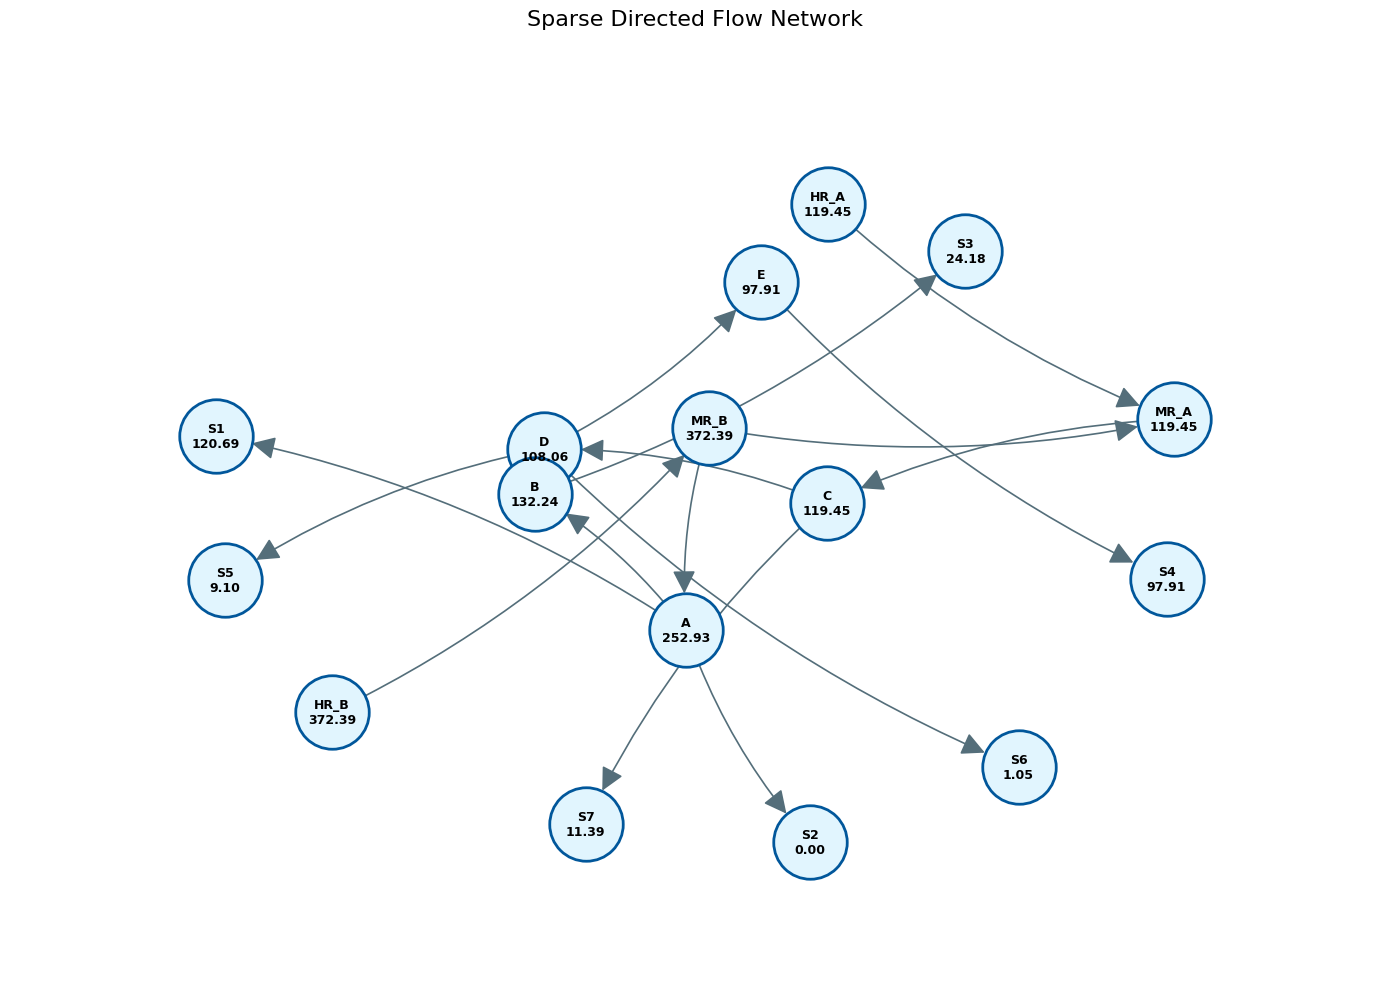

In [9]:
def display_sparse_flow_graph(G, node_values):
    """
    Displays a DiGraph with a very sparse layout and clear directions.
    """
    plt.figure(figsize=(14, 10)) # Increased figure size for more breathing room
    
    # k: The optimal distance between nodes. Increase this for more sparsity.
    # Default is approx 1/sqrt(n). Setting it to 2.0+ makes it very sparse.
    pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)
    
    # 1. Draw Nodes
    nx.draw_networkx_nodes(
        G, pos, 
        node_size=2800, # Slightly larger for better label fitting
        node_color='#E1F5FE', 
        edgecolors='#01579B',
        linewidths=2
    )
    
    # 2. Draw Edges with corrected arrowstyle and node_size clipping
    nx.draw_networkx_edges(
        G, pos, 
        arrows=True, 
        arrowstyle='-|>', 
        arrowsize=35, 
        edge_color='#546E7A',
        width=1.2,
        connectionstyle='arc3,rad=0.1',
        node_size=2800 # Match node_size to ensure arrows stop at the border
    )
    
    # 3. Add Labels
    labels = {n: f"{n}\n{node_values.get(n, 0):.2f}" for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')

    plt.title("Sparse Directed Flow Network", fontsize=16, pad=30)
    plt.axis('off')
    
    # Use margins to ensure nodes near the edge aren't cut off
    plt.margins(0.15) 
    plt.tight_layout()
    plt.show()



display_sparse_flow_graph(G_router, RAW_DATA.sample(1).to_dict('records')[0])

## VERIFY

In [10]:
def build_node_conservation_matrix_numpy(G, node_list):
    """
    Constructs a matrix where every row represents a Conservation Equation:
    Equation: Flow(Parent) - Sum(Flow(Children)) = 0
    
    Args:
        G (nx.DiGraph): The network topology.
        node_list (list): List of node names in the exact order of your data columns.
        
    Returns:
        np.ndarray: Matrix of shape [Num_Constraints, Num_Nodes]
        list: Labels for the rows (which Parent node each row represents)
    """
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)
    
    constraints = []
    row_labels = [] 
    
    # Iterate over every node to see if it acts as a Parent (Source/Router)
    for parent in G.nodes():
        children = list(G.successors(parent))
        
        # If it has no children (Sink), there is no downstream flow to check
        if len(children) == 0:
            continue
            
        # Create a row of zeros
        row = np.zeros(num_nodes)
        
        # 1. The Parent (Source of flow) is Positive (+1)
        if parent in node_to_idx:
            row[node_to_idx[parent]] = 1.0
            
        # 2. The Children (Destination of flow) are Negative (-1)
        for child in children:
            if child in node_to_idx:
                row[node_to_idx[child]] = -1.0
                
        constraints.append(row)
        row_labels.append(parent)
        
    if not constraints:
        print("⚠️ Warning: No parent-child relationships found in Graph.")
        return np.zeros((0, num_nodes)), []

    # Stack into a single Matrix
    matrix = np.vstack(constraints)
    
    print(f"✅ Conservation Matrix Built: {matrix.shape}")
    print(f"   (Checking {matrix.shape[0]} Parent->Children groups)")
    
    return matrix, row_labels


INCIDENCE_MATRIX, row_labels = build_node_conservation_matrix_numpy(G_router, G_router.nodes())
INCIDENCE_MATRIX_DF = pd.DataFrame(INCIDENCE_MATRIX, columns=G_router.nodes(), index=row_labels)
INCIDENCE_MATRIX_DF

✅ Conservation Matrix Built: (9, 16)
   (Checking 9 Parent->Children groups)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_A,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR_B,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_B,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
B,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


In [11]:
def test_kirchhoff_numpy(matrix, row_labels, flow_dict, node_list):
    """
    Tests Kirchhoff's Law using a specific flow dictionary and numpy.
    
    Args:
        matrix (np.ndarray): The conservation matrix.
        row_labels (list): The list of parent names returned by the previous function.
        flow_dict (dict): Your data, e.g., {'HR_A': 500.0, 'S1': 10.0 ...}
        node_list (list): The master list of nodes (columns).
        
    Returns:
        pd.DataFrame: Report of violations.
    """
    # 1. Convert Dict to Vector (Aligned with node_list)
    # If a node is missing in the dict, assume 0.0
    flow_vector = np.array([flow_dict.get(node, 0.0) for node in node_list])
    
    # 2. Perform The Physics Check (Matrix Multiplication)
    # [Constraints, Nodes] @ [Nodes] -> [Constraints]
    # Result = Parent_Flow - Sum(Children_Flow)
    imbalances = np.dot(matrix, flow_vector)
    
    # 3. Generate Report
    report_data = []
    
    for i, parent_name in enumerate(row_labels):
        net_balance = imbalances[i]
        
        # Get the Parent's flow for context (to calculate percentage)
        parent_flow = flow_dict.get(parent_name, 1e-6)
        if parent_flow == 0: parent_flow = 1e-6
        
        error_pct = (abs(net_balance) / abs(parent_flow)) * 100
        
        status = "✅ OK"
        if error_pct > 5.0: # Threshold 5%
            status = "❌ LEAK"
            
        report_data.append({
            'Parent_Node': parent_name,
            'Net_Balance': round(net_balance, 2),
            'Parent_Vol': round(parent_flow, 2),
            'Error_%': round(error_pct, 2),
            'Status': status
        })
        
    df_report = pd.DataFrame(report_data)
    
    # Sort by Error magnitude to show worst offenders first
    df_report = df_report.sort_values(by='Error_%', ascending=False)
    
    return df_report


_rand_flow = RAW_DATA.sample(1).iloc[0].to_dict()
display(pd.DataFrame(_rand_flow, index=[0]))

test_kirchhoff_numpy(INCIDENCE_MATRIX, row_labels, _rand_flow, G_router.nodes())


,S7,S6,S5,S3,S1,S2,S4,E,D,B,C,A,MR_A,MR_B,HR_A,HR_B
0,0.0,31.856353,19.253984,3.701613,18.567568,0.201035,10.277027,10.277027,61.387364,65.088977,61.387364,83.85758,61.387364,145.244944,61.387364,145.244944


,Parent_Node,Net_Balance,Parent_Vol,Error_%,Status
0,HR_A,0.0,61.39,0.0,✅ OK
1,MR_A,0.0,61.39,0.0,✅ OK
2,HR_B,0.0,145.24,0.0,✅ OK
3,MR_B,0.0,145.24,0.0,✅ OK
4,C,0.0,61.39,0.0,✅ OK
5,D,0.0,61.39,0.0,✅ OK
6,A,0.0,83.86,0.0,✅ OK
7,B,0.0,65.09,0.0,✅ OK
8,E,0.0,10.28,0.0,✅ OK


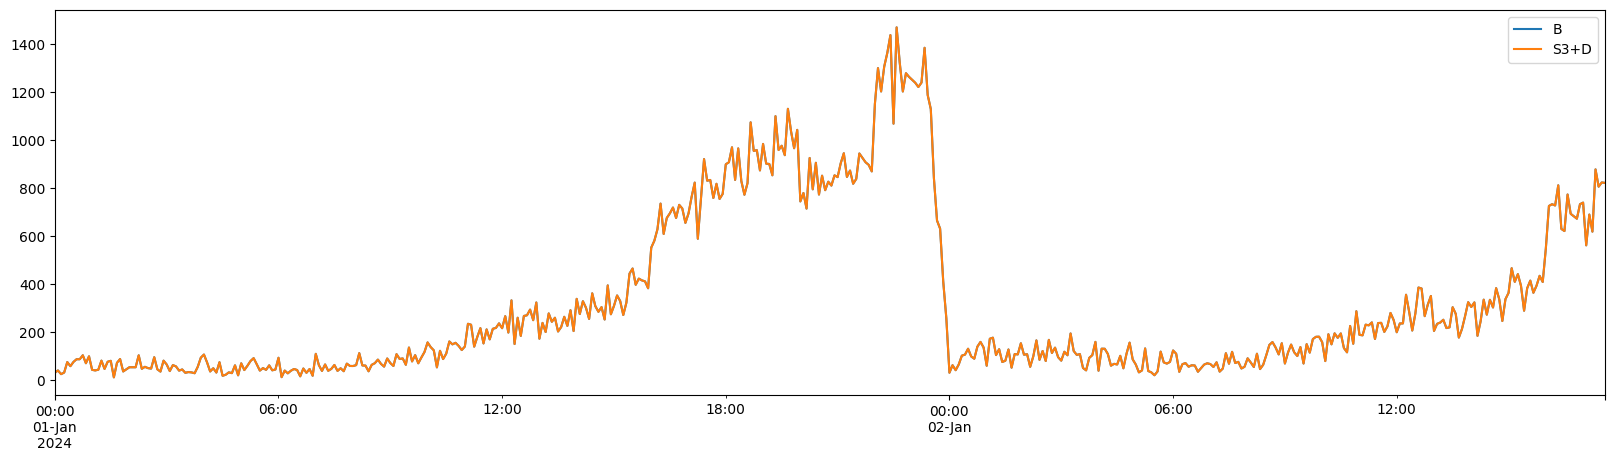

In [12]:
import matplotlib.pyplot as plt

RAW_DATA[['B']].sum(axis=1).iloc[0:500].plot(label='B', figsize=(20,5))
RAW_DATA[['S3','D']].iloc[0:500].sum(axis=1).plot(label='S3+D')

plt.legend()



## FINAL PREPARATION



In [13]:

############################################## SIULATING NOISE ################################
if NOISE_RANGE > 0:
    NOISE =  np.random.uniform(-NOISE_RANGE, NOISE_RANGE,size=RAW_DATA.shape)
else:
    print(f"No Noise")
    NOISE = 0
    
RAW_DATA = RAW_DATA*(1+NOISE)
RAW_DATA = RAW_DATA.T



No Noise


## PREPARATION OF DATA

In [14]:
SAMPLING = '5min' #1h
TSS = RAW_DATA.T.copy()
TSS = TSS.resample(SAMPLING).mean()
TSS = TSS[np.array(G_router.nodes())]
TSS

,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,23.671425,23.671425,77.469651,77.469651,23.671425,22.316587,53.798225,31.667456,10.038462,1.354839,4.450000,7.828125,9.350870,21.738462,0.392308,10.038462
2024-01-01 00:05:00,23.671425,23.671425,87.281199,87.281199,23.671425,22.316587,63.609774,41.479004,10.038462,1.354839,4.450000,7.828125,19.162418,21.738462,0.392308,10.038462
2024-01-01 00:10:00,23.671425,23.671425,71.858222,71.858222,23.671425,22.316587,48.186797,26.056028,10.038462,1.354839,4.450000,7.828125,3.739441,21.738462,0.392308,10.038462
2024-01-01 00:15:00,23.671425,23.671425,78.363256,78.363256,23.671425,22.316587,54.691831,32.561061,10.038462,1.354839,4.450000,7.828125,10.244475,21.738462,0.392308,10.038462
2024-01-01 00:20:00,54.785056,54.785056,205.535703,205.535703,54.785056,52.599284,150.750646,76.327358,0.000000,2.185772,7.473280,45.126004,23.728074,73.829364,0.593925,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 23:35:00,913.890189,913.890189,2867.808826,2867.808826,913.890189,871.348856,1953.918637,969.530674,574.933333,42.541333,78.120000,218.295522,98.181818,976.402778,7.985185,574.933333
2024-06-28 23:40:00,607.506945,607.506945,1972.933300,1972.933300,607.506945,571.890945,1365.426355,613.345491,328.533333,35.616000,95.480000,147.877612,41.454545,745.616667,6.464198,328.533333
2024-06-28 23:45:00,364.950408,364.950408,1672.432783,1672.432783,364.950408,338.238408,1307.482375,397.147499,176.000000,26.712000,63.653333,98.585075,58.909091,905.391667,4.943210,176.000000
2024-06-28 23:50:00,392.767323,392.767323,1354.821339,1354.821339,392.767323,375.948657,962.054016,408.675929,211.200000,16.818667,52.080000,112.668657,32.727273,550.336111,3.041975,211.200000


## TESTS

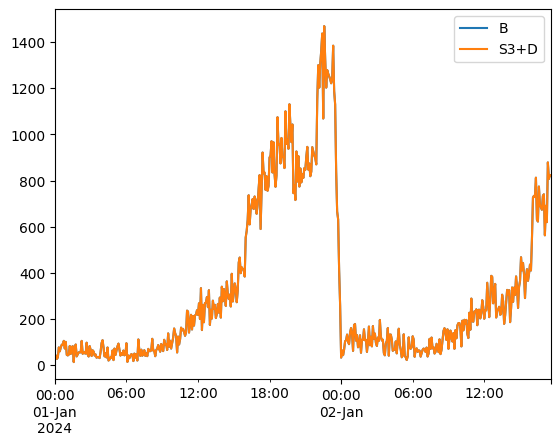

In [15]:
TSS[['B']].sum(axis=1).iloc[0:500].plot(label='B')
TSS[['S3','D']].iloc[0:500].sum(axis=1).plot(label='S3+D')
plt.legend()

In [16]:
from pyvis.network import Network
from IPython.display import HTML

def show_interactive_graph(G, flows):
    G_draw = G.copy()
    nx.set_node_attributes(G_draw, flows, name='flow')

 
    net = Network(directed=True, notebook=True, cdn_resources='remote')

    # Add nodes and edges
    for node, attr in G_draw.nodes(data=True):
        net.add_node(node, label=f"{node}:{attr['flow']:.2f}")
    
    for edge in G_draw.edges():
        net.add_edge(edge[0], edge[1])

    # Enable the physics engine for interactive movement
    net.show_buttons(filter_=['physics']) 
    net.show("interactive_graph.html")


show_interactive_graph(G_router, TSS.sample(1).iloc[0].to_dict())

interactive_graph.html


In [17]:
print(f"Saving Data in {SAVE_PATH}")
TSS.to_parquet(SAVE_PATH)

Saving Data in Sim_Raw_data.parquet


In [18]:
import json

def save_graph_to_json(G, filename):
    # Convert the graph to a JSON-serializable dictionary
    data = nx.node_link_data(G)
    
    with open(filename, 'w') as f:
        json.dump(data, f, indent=4)
    print(f"Graph saved to {filename}")

save_graph_to_json(G_router, SAVE_PATH_GRAPH)

Graph saved to Sim_Graph.json
